In [11]:
import cv2 # opencv-python
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
def detect_color_blob(frame, lower_bounds, upper_bounds):
    """
    Detect the largest color blob in the frame and return its centroid (x, y).
    Returns:
        (x, y, mask, annotated_frame)
        x, y are None if no color object is detected.
    """
    annotated = frame.copy()

    # Convert to HSV for robust color thresholding
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Masker maken (ondersteunt 1 of meerdere HSV-ranges)
    mask = cv2.inRange(hsv, lower_bounds[0], upper_bounds[0])

    # 2. Loop door eventuele volgende ranges en voeg ze samen
    for i in range(1, len(lower_bounds)):
        mask2 = cv2.inRange(hsv, lower_bounds[i], upper_bounds[i])
        mask = cv2.bitwise_or(mask, mask2)

    # Clean up mask
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None, None, mask, annotated

    # Pick largest contour
    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)

    # Ignore tiny detections
    if area < 10:                # verlaagd van 10 naar 3 omdat bij onscherpe delen het opp kan worden verlaagd.
        return None, None, mask, annotated

    M = cv2.moments(largest)
    if M["m00"] == 0:
        return None, None, mask, annotated

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    # Draw detected point
    cv2.circle(annotated, (cx, cy), 6, (0, 255, 0), -1)
    cv2.drawContours(annotated, [largest], -1, (255, 0, 0), 2)
    cv2.putText(
        annotated,
        f"({cx}, {cy})",
        (cx + 10, cy - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA
    )

    return cx, cy, mask, annotated

In [13]:
# process video voor groene en rode bolletje
def process_video(video_path, output_csv, preview=True, save_annotated=False):
    video_path = Path(video_path)
    if not video_path.exists():
        raise FileNotFoundError(f"Video file not found: {video_path}")

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = None
    if save_annotated:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        annotated_path = video_path.with_name(video_path.stem + "_tracked.mp4")
        writer = cv2.VideoWriter(str(annotated_path), fourcc, fps, (width, height))

    # Red wraps around in HSV, so use two ranges
    lower_red1 = np.array([0, 80, 50])
    upper_red1 = np.array([10, 255, 255])

    lower_red2 = np.array([170, 80, 50])
    upper_red2 = np.array([180, 255, 255])
    
    red_lowers = [lower_red1, lower_red2]
    red_uppers = [upper_red1, upper_red2]

    # HSV grenzen voor Groen
    green_lowers = [np.array([35, 50, 50])]
    green_uppers = [np.array([85, 255, 255])]

    results = []
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        rx, ry, red_mask, annotated = detect_color_blob(frame, red_lowers, red_uppers)
        gx, gy, green_mask, annotated = detect_color_blob(frame, green_lowers, green_uppers)

        time_s = frame_idx / fps if fps > 0 else np.nan

        results.append({
            "frame": frame_idx,
            "time_s": time_s,
            "rx": rx,
            "ry": ry,
            "gx": gx,
            "gy": gy
        })

        if writer is not None:
            writer.write(annotated)

        if preview:
            combined_mask = cv2.cvtColor(red_mask, cv2.COLOR_GRAY2BGR)
            top = np.hstack((frame, annotated))
            bottom = np.hstack((combined_mask, np.zeros_like(combined_mask)))
            display = np.vstack((top, bottom))

            scale = 0.7
            display = cv2.resize(display, None, fx=scale, fy=scale)

            cv2.imshow("Original | Annotated / Mask", display)

            key = cv2.waitKey(1) & 0xFF
            if key == ord("q"):
                break

        frame_idx += 1

    cap.release()
    if writer is not None:
        writer.release()
    cv2.destroyAllWindows()

    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)

    print(f"Done. Saved coordinates to: {output_csv}")
    if save_annotated:
        print(f"Saved annotated video to: {annotated_path}")

    missing = df["rx"].isna().sum() # Of vervang door "rx"
    print(f"Frames processed: {len(df)}")
    print(f"Frames with missing red detection: {missing}")

In [14]:
video = Path("C:/Users/Eline/OneDrive/Pictures/Double Pendulum-TN23010/IMG_9489.MOV")
output = "20260710_141788.csv"

process_video(
        video_path=video,
        output_csv=output,
        preview=True,
        save_annotated=True
    )

Done. Saved coordinates to: 20260710_141788.csv
Saved annotated video to: C:\Users\Eline\OneDrive\Pictures\Double Pendulum-TN23010\IMG_9489_tracked.mp4
Frames processed: 596
Frames with missing red detection: 0


In [15]:
# Kalibratie : pixels per cm
# omdat in het eerste frame van elke video een hand zit, kijken we voor kalibratie naar frame in het midden

## Coordinatien van rode bolletje detecteren
# Kies je videopad en het gewenste frame-nummer
video_path = Path("IMG_9456.MOV")
frame_index = 485  # <--- Pas dit getal aan naar het frame dat jij wilt hebben!
# frame waarin het rode bolletje in rust is. Ik kijk in 430 - 553
#Open de video en ga naar het juiste frame
red_lowers = [np.array([0, 80, 50]), np.array([170, 80, 50])]
red_uppers = [np.array([10, 255, 255]), np.array([180, 255, 255])]

cap = cv2.VideoCapture(str(video_path))
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)

success, frame = cap.read()
cap.release()

if not success or frame is None:
    print(f"Kon frame {frame_index} niet inlezen.")
else:
    # Roep jouw bestaande functie aan op dit frame\
    rx, ry, red_mask, annotated_frame_red = detect_color_blob(frame, red_lowers, red_uppers)

    if rx is not None and ry is not None:
        print(f"Rood punt gevonden op frame {frame_index}: X = {rx}, Y = {ry}")
        
        # plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
        # plt.show()
    else:
        print(f"Geen rood punt kunnen vinden in frame {frame_index}.")

# Sla de geannoteerde afbeelding op ter controle
cv2.imwrite("calibration_check_redpoint1.png", annotated_frame_red)
print("Annotated calibration image saved as 'calibration_check_redpoint1.png'.")

# Plot de afbeelding met pixelraster
ann1_rgb = cv2.cvtColor(annotated_frame_red, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 10), dpi=450)
plt.imshow(ann1_rgb)
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.title(f"Frame {frame_index} met gedetecteerd rood punt: x={rx}, y={ry}")
plt.grid(True, color='yellow', linestyle='--', linewidth=0.5)
plt.show()

Kon frame 485 niet inlezen.


NameError: name 'annotated_frame_red' is not defined

Groen punt gevonden op frame 485: X = 1651, Y = 1903
Opgeslagen als 'calibration_check_greenpoint1.png'.


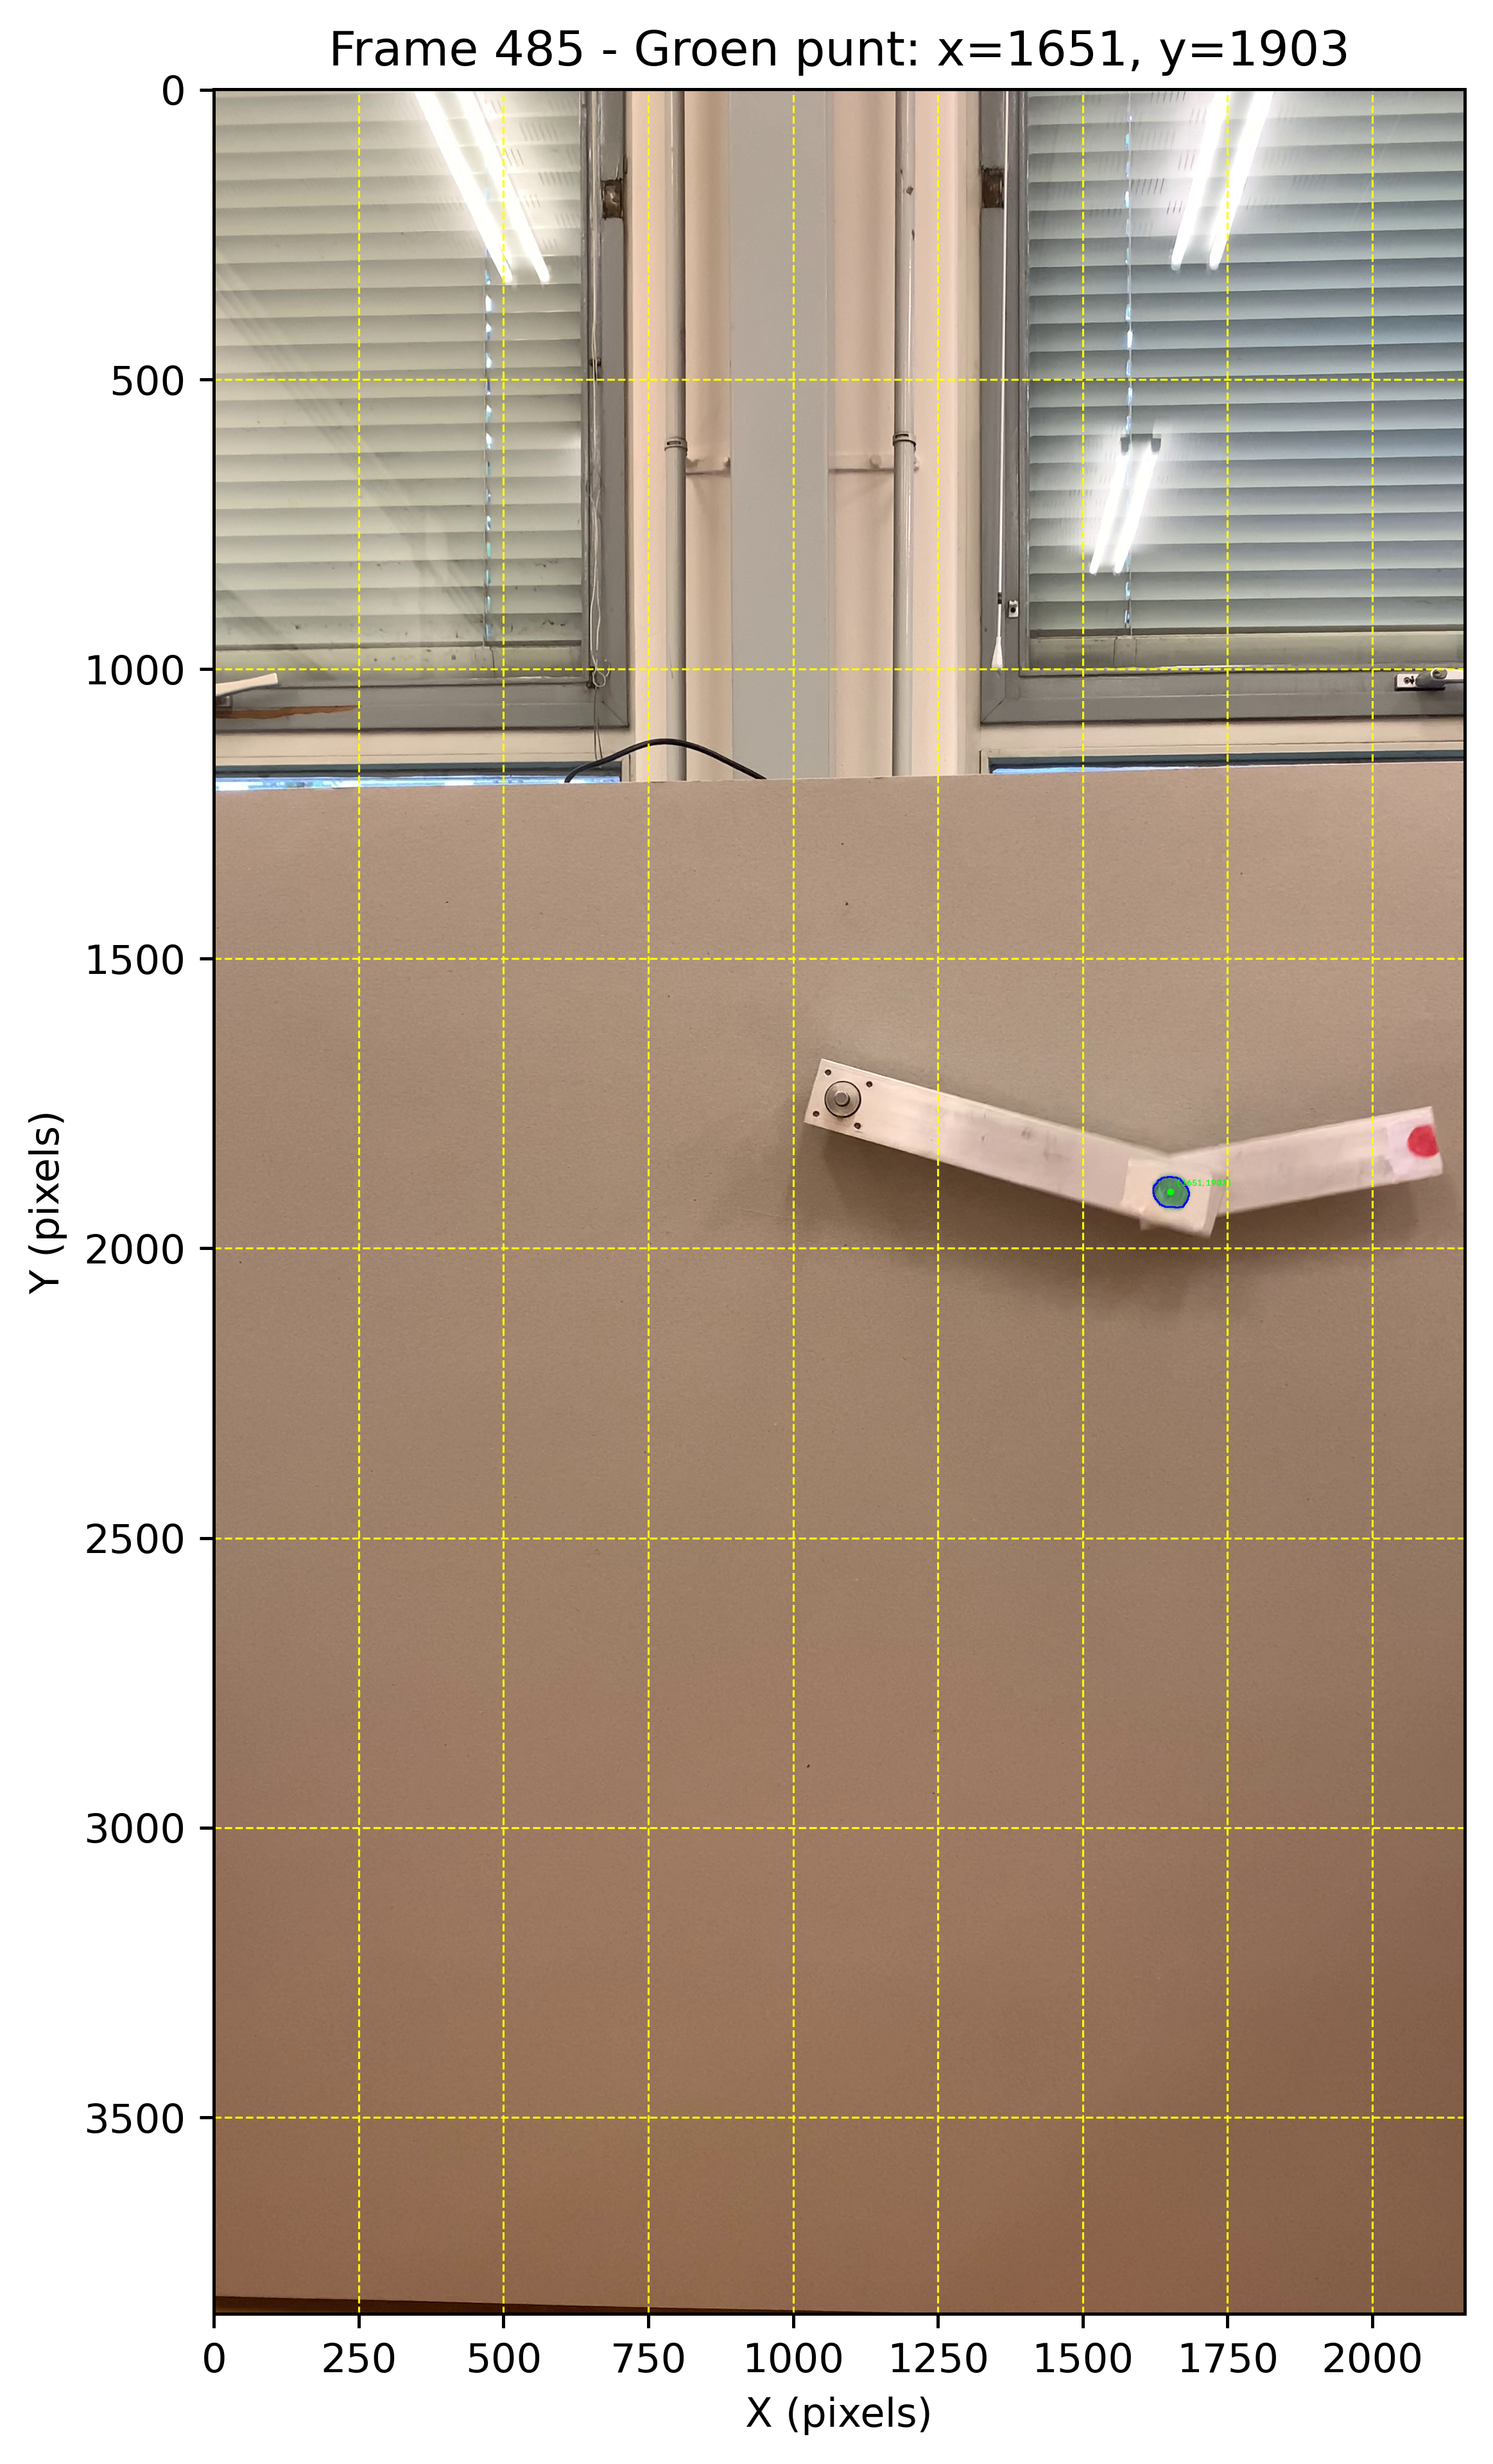

In [ ]:
## Coordinatien van groene bolletje detecteren

green_lowers = [np.array([35, 50, 50])]
green_uppers = [np.array([85, 255, 255])]

cap = cv2.VideoCapture(str(video_path))
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
success, frame = cap.read()
cap.release()

if not success or frame is None:
    print(f"Kon frame {frame_index} niet inlezen voor het groene punt.")
else:
    # Gebruik óók hier detect_color_blob
    gx, gy, green_mask, annotated_frame_green = detect_color_blob(frame, green_lowers, green_uppers)

    if gx is not None and gy is not None:
        print(f"Groen punt gevonden op frame {frame_index}: X = {gx}, Y = {gy}")
        
        cv2.imwrite("calibration_check_greenpoint1.png", annotated_frame_green)
        print("Opgeslagen als 'calibration_check_greenpoint1.png'.")

        # Plotten
        ann_green_rgb = cv2.cvtColor(annotated_frame_green, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 10), dpi=450)
        plt.imshow(ann_green_rgb)
        plt.xlabel("X (pixels)")
        plt.ylabel("Y (pixels)")
        plt.title(f"Frame {frame_index} - Groen punt: x={gx}, y={gy}")
        plt.grid(True, color='yellow', linestyle='--', linewidth=0.5)
        plt.show()
    else:
        print(f"Geen groen punt kunnen vinden in frame {frame_index}.")

In [ ]:
# Pixels per cm berekenen
green_to_red = 0.1507 #m
u_L = 0.001

bekende_afstand_cm = green_to_red      # L (werkelijke afstand in cm)
onzekerheid_cm = u_L           # Delta L (meetfout liniaal)
onzekerheid_pixels_punt = 1.0  # Onzekerheid van één punt in pixels

if 'rx' in locals() and 'gx' in locals() and rx is not None and gx is not None:
    
    # 1. Afstand in pixels berekenen (D)
    D = np.sqrt((gx - rx)**2 + (gy - ry)**2)
          
    # 2. Conversiefactor (C = D / L)
    pixels_per_cm = D / bekende_afstand_cm
    
    # Onzekerheid in pixels (Delta D) door foutfortplanting van X en Y coördinaten
    # (D is een functie van rx, ry, gx, gy. De afgeleiden hiervan geven een onzekerheid van sqrt(2) * onzekerheid_punt)
    delta_D = np.sqrt(2) * onzekerheid_pixels_punt 

    # Partiële afgeleide naar D: dC/dD = 1 / L
    dC_dD = 1.0 / bekende_afstand_cm
    
    # Partiële afgeleide naar L: dC/dL = -D / (L^2)
    dC_dL = -D / (bekende_afstand_cm**2)
    
    # Totale differentiaal (foutfortplanting formule)
    onzekerheid_pixels_per_cm = np.sqrt( (dC_dD * delta_D)**2 + (dC_dL * onzekerheid_cm)**2 )
    
    print(f"Resultaat: {pixels_per_cm:.4f} ± {onzekerheid_pixels_per_cm:.4f} px/cm")

else:
    print("Fout: Geen geldige coördinaten gevonden.")

Resultaat: 2948.9099 ± 21.7020 px/cm


In [ ]:
def export_first_frame(
    video_path,
    output_png=None,
    dpi=300
):
    """
    Export the first frame of a video as a PNG.

    The exported image keeps exactly the same pixel width and height
    as the original video frame.

    Parameters
    ----------
    video_path : str or Path
        Path to the input video.

    output_png : str or Path, optional
        Output PNG path. If None, the output name will be:
        <video_name>_first_frame.png

    dpi : float
        DPI metadata written to the PNG.
        DPI does not change the number of pixels or image quality.
    """

    video_path = Path(video_path)

    if not video_path.exists():
        raise FileNotFoundError(
            f"Video file not found: {video_path}"
        )

    if output_png is None:
        output_png = video_path.with_name(
            video_path.stem + "_first_frame.png"
        )
    else:
        output_png = Path(output_png)

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(
            f"Could not open video: {video_path}"
        )

    success, frame = cap.read()
    cap.release()

    if not success or frame is None:
        raise RuntimeError(
            "Could not read the first frame from the video."
        )

    height, width = frame.shape[:2]

    # OpenCV writes the original pixel data without resizing.
    success = cv2.imwrite(
        str(output_png),
        frame,
        [cv2.IMWRITE_PNG_COMPRESSION, 3]
    )

    if not success:
        raise RuntimeError(
            f"Could not save PNG: {output_png}"
        )

    # OpenCV does not reliably write DPI metadata, so add it using Pillow.
    try:
        from PIL import Image

        with Image.open(output_png) as image:
            image.save(
                output_png,
                dpi=(dpi, dpi)
            )

    except ImportError:
        print(
            "Pillow is not installed, so DPI metadata was not added."
        )
        print(
            "Install it with: pip install pillow"
        )

    print(f"Saved first frame to: {output_png}")
    print(f"Resolution: {width} x {height} pixels")
    print(f"DPI metadata: {dpi} DPI")

    return output_png

In [ ]:
export_first_frame(
    video_path=video,
    output_png="20260710_141408_first_frame.png",
    dpi=300
)

Saved first frame to: 20260710_141408_first_frame.png
Resolution: 2160 x 3840 pixels
DPI metadata: 300 DPI


WindowsPath('20260710_141408_first_frame.png')

Onzekerheid in pixels per meter is: 2170.195488408052 px/m


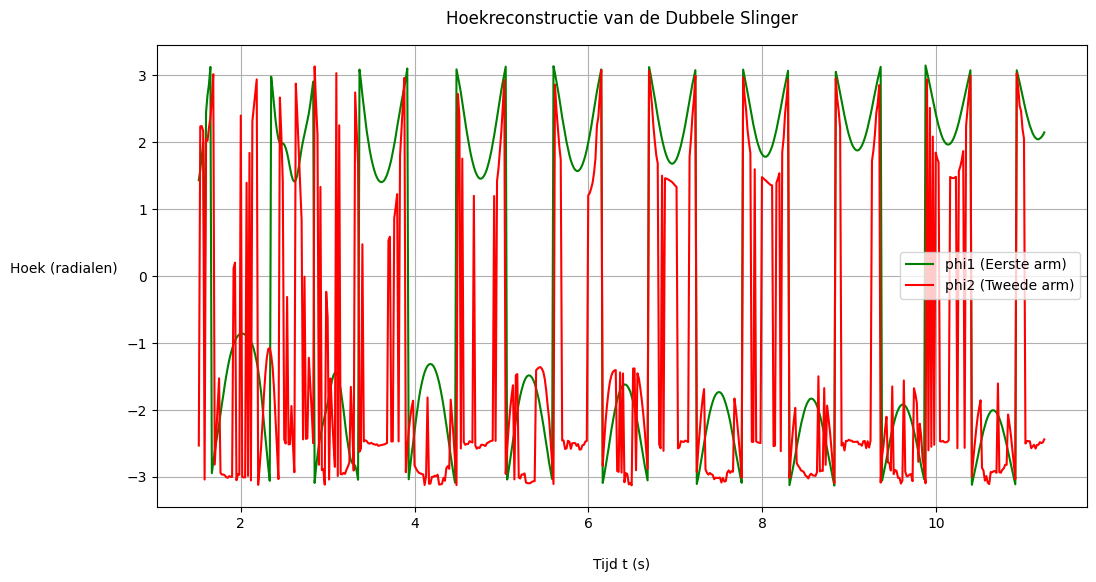

In [ ]:
#. Laad de CSV die zojuist is opgeslagen
csv_file = "20260710_141408.csv"  # Vervang dit door jouw bestandsnaam
df = pd.read_csv(csv_file)

# Filter de hand (eerste 1.5 seconden)
df = df[df['time_s'] >= 1.5].copy() 
df['tau'] = df['time_s'] - df['time_s'].iloc[0] # Relatieve tijd vanaf start

# scharnierpunt
pivot_x = 1075          # X-pixelwaarde van het vaste scharnier 
pivot_y = 1750          # Y-pixelwaarde van het vaste scharnier
pixels_per_meter = pixels_per_cm *100
u_px_per_m = onzekerheid_pixels_per_cm * 100  
print(f'Onzekerheid in pixels per meter is: {u_px_per_m} px/m')

# Omrekenen naar meters ten opzichte van het scharnier, dus scharnier is oorsprong
# y in pixels loopt naar beneden
df['gx_m'] = (df['gx'] - pivot_x) / pixels_per_meter
df['gy_m'] = (pivot_y - df['gy']) / pixels_per_meter

df['rx_m'] = (df['rx'] - pivot_x) / pixels_per_meter
df['ry_m'] = (pivot_y - df['ry']) / pixels_per_meter

# Reconstructie van de absolute hoeken phi1 (groen)
# hoek van het groene punt ten opzichte van het vaste scharnier
df['phi1'] = np.arctan2(df['gx_m'], df['gy_m'])

# hoek van het rode punt ten opzichte van het groene punt (tweede arm)
dx = df['rx_m'] - df['gx_m']
dy = df['ry_m'] - df['gy_m']
df['phi2'] = np.arctan2(dx, dy)

# Plot phi1(t) en phi2(t)
plt.figure(figsize=(12, 6))
plt.plot(df['time_s'], df['phi1'], label='phi1 (Eerste arm)', color='green')
plt.plot(df['time_s'], df['phi2'], label='phi2 (Tweede arm)', color='red')
plt.xlabel('Tijd t (s)', labelpad=20)
plt.ylabel('Hoek (radialen)', rotation=0, labelpad=45)
plt.title('Hoekreconstructie van de Dubbele Slinger', pad=15)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from scipy.signal import savgol_filter

m1 = 540.6 / 1000      # kg 
m2 = 200.1 / 1000      # kg
L1 = 0.205             # m
green_to_red = 0.1507  # m (L2)

# ==========================================
# 2. DATA LADEN EN FILTEREN
# ==========================================
df = pd.read_csv("20260710_141408.csv")

# Verwijder de eerste 1.5 seconden (waar de hand nog in beeld is)
df = df[df['time_s'] >= 1.5].copy()
df['tau'] = df['time_s'] - df['time_s'].iloc[0]

# Print beschikbare kolommen ter controle
print("Beschikbare kolommen in je CSV:", df.columns.tolist())

# ==========================================
# 3. HOEKEN OMSCHALEN & UNWRAP (VOORKOM SPRONGEN)
# ==========================================
# Check of hoeken in graden staan (zo ja, zet om naar radialen)
if df['phi1'].abs().max() > 2 * np.pi:
    phi1_rad = np.radians(df['phi1'].values)
    phi2_rad = np.radians(df['phi2'].values)
else:
    phi1_rad = df['phi1'].values
    phi2_rad = df['phi2'].values

# Unwrap voorkomt kunstmatige pieken van +pi naar -pi bij doordraaien
theta1 = np.unwrap(phi1_rad)
theta2 = np.unwrap(phi2_rad)

# Opslaan in dataframe
df['theta1'] = theta1
df['theta2'] = theta2

# ==========================================
# 4. HOEKSNELHEDEN BEREKENEN (SAVITZKY-GOLAY)
# ==========================================
dt = np.mean(np.diff(df['tau']))

# Savitzky-Golay filter voorkomt dat pixelruis wordt uitvergroot bij differentiëren
window_len = 15  # Moet een oneven getal zijn
omega1 = savgol_filter(theta1, window_length=window_len, polyorder=3, deriv=1, delta=dt)
omega2 = savgol_filter(theta2, window_length=window_len, polyorder=3, deriv=1, delta=dt)

df['omega1'] = omega1
df['omega2'] = omega2

# ==========================================
# 5. IMPULSEN BEREKENEN (p1 EN p2)
# ==========================================
cos_diff = np.cos(theta1 - theta2)

df['p1'] = (m1 + m2) * (L1**2) * omega1 + m2 * L1 * green_to_red * omega2 * cos_diff
df['p2'] = m2 * (green_to_red**2) * omega2 + m2 * L1 * green_to_red * omega1 * cos_diff

# ==========================================
# 6. DIMENSIELOOS MAKEN EN FASERUIMTE-AFSTAND
# ==========================================
# Normen bepalen
theta_norm = np.pi                     # Max/min bereik van hoeken is pi
p1_norm = np.max(np.abs(df['p1']))     # Maximale absolute impuls 1 uit experiment
p2_norm = np.max(np.abs(df['p2']))     # Maximale absolute impuls 2 uit experiment

# Dimensieloze variabelen berekenen
# Gebruik de modulus van theta om de hoek weer binnen [-pi, pi] te schalen voor de normering
df['phi1_dimless'] = ((theta1 + np.pi) % (2 * np.pi) - np.pi) / theta_norm
df['phi2_dimless'] = ((theta2 + np.pi) % (2 * np.pi) - np.pi) / theta_norm
df['p1_dimless'] = df['p1'] / p1_norm
df['p2_dimless'] = df['p2'] / p2_norm

# Faseruimte-afstand delta(tau) berekenen (afstand tot de oorsprong in de 4D-faseruimte)
df['delta'] = np.sqrt(
    (df['phi1_dimless'])**2 +
    (df['p1_dimless'])**2 +
    (df['phi2_dimless'])**2 +
    (df['p2_dimless'])**2
)

# ==========================================
# 7. VISUALISATIE / QUALITY CHECK
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Grafiek 1: Hoeksnelheden
axes[0].plot(df['tau'], df['omega1'], label='Hoeksnelheid 1 ($\omega_1$)', color='cyan')
axes[0].plot(df['tau'], df['omega2'], label='Hoeksnelheid 2 ($\omega_2$)', color='magenta')
axes[0].set_ylabel('Hoeksnelheid [rad/s]')
axes[0].set_title('Quality Check: Hoeksnelheden (Gefilterd)')
axes[0].legend()
axes[0].grid(True)

# Grafiek 2: Impulsen
axes[1].plot(df['tau'], df['p1'], label='Impuls 1 ($p_1$)', color='green')
axes[1].plot(df['tau'], df['p2'], label='Impuls 2 ($p_2$)', color='red')
axes[1].set_ylabel('Impuls [kg m²/s]')
axes[1].set_title('Quality Check: Impulsen')
axes[1].legend()
axes[1].grid(True)

# Grafiek 3: Dimensieloze Faseruimte-afstand delta(tau)
axes[2].plot(df['tau'], df['delta'], label='Faseruimte-afstand $\delta(\\tau)$', color='purple')
axes[2].set_xlabel('Tijd $\\tau$ [s]')
axes[2].set_ylabel('Afstand $\delta$ [-]')
axes[2].set_title('Dimensieloze Faseruimte-afstand tot de Oorsprong')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

Beschikbare kolommen in je CSV: ['frame', 'time_s', 'rx', 'ry', 'gx', 'gy', 'tau']


KeyError: 'phi1'

### notes
Te zien is dat phi1 negatief begint en dan erg snel positief wordt door negaitve gx en gy coordinaat. Phi1 is volgt meerendeels het verwachte patroon van een enkele slinger. Het uitwijken bij hoge potentiële energiën op 3 en -3 radialen, en de hoge snelheid van wisseling daarvan. Phi2 volgt een chaotischer bestaan. In seconde 5-6 zie je op de video dat de tweede arm geen rotaties om het groene punt maakt. Er is ook meteen in de grafiek te zien dat phi2 dan meer de enkele slinger met wat naschommelingen achtervolgt.

In [ ]:
# volledige toestand van een dubbele slinger bestaat op elk moment uit 4 getallen tegelijk
# :Hoek 1 phi1, Impuls 1 ($p_1$), Hoek 2 (phi2), Impuls 2 ($p_2$)
# Deze 4 getallen samen vormen een faseruimte.
# om te zorgen dat je faseruimte 1 in video 1 vergelijkt met faseruimte 2 in video 2
# moet je hoeken en impulsen bij elkaar optellen door ze dimensieloos te maken.
# Elk getal moet gedeeld worden door zijn norm of maximum.
# voor hoeken is het maximum/minimum, pi/-pi. 
# voor impuls is het maximum bepaald uit experimetn
m1 = 540.6/1000      #kg 
m2 = 200.1/1000
u_m = 0.1 /1000      # kg
L1 = 0.205      #m
# L2 = 0.161
green_to_red = 0.1507
# u_L = 0.001

df = pd.read_csv("20260710_141408.csv")
df = df[df['time_s'] >= 1.5].copy()  # Pas 1.5 aan naar jouw starttijd, want hand zit nog in eerste 1.5 sec
df['tau'] = df['time_s'] - df['time_s'].iloc[0]     # tau is tijdstip van eerste frame
# Print alle kolomnamen om te kijken hoe ze exact heten
print("Beschikbare kolommen in je CSV:", df.columns.tolist())

# Wanneer de slinger ronddraait of het nulpunt passeert, springt de hoek in videotracking plotseling van $+\pi$ naar $-\pi$ (of $180^\circ$ naar $-180^\circ$)

dt = np.mean(np.diff(df['tau']))        # gemiddelde tijdstap tussen twee opeenvolgende frames.
df['omega1'] = np.gradient(df['phi1'], dt)
df['omega2'] = np.gradient(df['phi2'], dt)
theta1 = df['phi1']
theta2 = df['phi2']
omega1 = df['omega1']
omega2 = df['omega2']

# Koppelingsfactor vanwege de hoekverschillen
cos_diff = np.cos(theta1 - theta2)
# want p1 = dT/dtheta1. dus impuls i is part. afgeleide van kin energy naar theta i.
#  p1
df['p1'] = (m1 + m2) * (L1**2) * omega1 + m2 * L1 * green_to_red * omega2 * cos_diff

# p2
df['p2'] = m2 * (green_to_red**2) * omega2 + m2 * L1 * green_to_red * omega1 * cos_diff

# Controleer of de curves glad (smooth) en consistent zijn
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Bovenste grafiek: Hoeksnelheden
axes[0].plot(df['tau'], df['omega1'], label='Hoeksnelheid 1 ($\omega_1$)', color='cyan')
axes[0].plot(df['tau'], df['omega2'], label='Hoeksnelheid 2 ($\omega_2$)', color='magenta')
axes[0].set_ylabel('Hoeksnelheid [rad/s]')
axes[0].set_title('Quality Check: Hoeksnelheden')
axes[0].legend()
axes[0].grid(True)

# Onderste grafiek: Impulsen (nu op axes[1] i.p.v. axes[0])
axes[1].plot(df['tau'], df['p1'], label='Impuls 1 ($p_1$)', color='green')
axes[1].plot(df['tau'], df['p2'], label='Impuls 2 ($p_2$)', color='red')
axes[1].set_xlabel('Tijd $\tau$ [s]')
axes[1].set_ylabel('Impuls [kg m²/s]') # Impuls van een slinger heeft door m*L^2 ook een kwadraat in de eenheid
axes[1].set_title('Quality Check: Impulsen')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Beschikbare kolommen in je CSV: ['frame', 'time_s', 'rx', 'ry', 'gx', 'gy', 'tau']


KeyError: 'phi1'

In [ ]:
# Normalisatieschalen (Kies logische waardes, bijv. maximale bereik of typische fluctuatie)
theta_norm = np.pi  # max= pi radialen
p1_norm = np.max(np.abs(df['p1']))  # De piekwaarde van impuls 1 in jouw experiment
p2_norm = np.max(np.abs(df['p2']))  # De piekwaarde van impuls 2 in jouw experimen

# Nu bereken je de faseruimte-afstand delta(tau)
df['delta'] = np.sqrt(
    (df['phi1'] / theta1_norm)**2 +
    (df['p1'] / p1_norm)**2 +
    (df['phi2'] / theta2_norm)**2 +
    (df['p2'] / p2_norm)**2
)

print()